In [2]:
from tensorflow.keras.datasets import imdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix , classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences

The `imdb` dataset returns sequences of word indices. For a `Dense` layer, we need fixed-size input vectors. Let's preprocess the data using multi-hot encoding to convert these sequences into vectors indicating the presence of words up to `num_words`.

In [3]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
max_len = 256
X_train_padded = pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


* epochs = 10
* batch_size = 20

In [ ]:
model_relu_p = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [ ]:

model_relu_.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [11]:


history = model_relu.fit(X_train_padded, y_train, epochs=20, batch_size=20, validation_split=0.2)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7812 - loss: 0.4362 - val_accuracy: 0.8648 - val_loss: 0.3287
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9547 - loss: 0.1269 - val_accuracy: 0.8278 - val_loss: 0.5179
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9908 - loss: 0.0277 - val_accuracy: 0.8366 - val_loss: 0.7711
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9929 - loss: 0.0193 - val_accuracy: 0.8294 - val_loss: 0.8230
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9956 - loss: 0.0128 - val_accuracy: 0.8326 - val_loss: 0.8784
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9947 - loss: 0.0153 - val_accuracy: 0.8166 - val_loss: 1.0852
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9969 - loss: 0.0092 - val_accuracy: 0.8312 - val_loss: 0.7933
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9965 - loss: 0.0108 - 

In [12]:


loss, accuracy = model_relu.evaluate(X_test_padded, y_test)
print("Test Accuracy:", accuracy)

y_pred = (model_relu.predict(X_test_padded) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8068 - loss: 2.0567
Test Accuracy: 0.8068400025367737
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

           0       0.87      0.72      0.79     12500
           1       0.76      0.89      0.82     12500

    accuracy                           0.81     25000
   macro avg       0.82      0.81      0.81     25000
weighted avg       0.82      0.81      0.81     25000



In [24]:
model_sigmoid = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    Flatten(),

    Dense(128, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(32, activation='sigmoid'),

    Dense(1, activation='sigmoid')
])

model_sigmoid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [25]:

history_sigmoid = model_sigmoid.fit(X_train_padded, y_train, epochs=20, batch_size=20, validation_split=0.2)


loss_sigmoid, accuracy_sigmoid = model_sigmoid.evaluate(X_test_padded, y_test)
print("\nModel with sigmoid Activation:")
print(f"Test Loss: {loss_sigmoid:.4f}")
print(f"Test Accuracy: {accuracy_sigmoid:.4f}")

y_pred_sigmoid = (model_sigmoid.predict(X_test_padded) > 0.5).astype("int32")
print("Classification Report for sigmoid Model:")
print(classification_report(y_test, y_pred_sigmoid))

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7681 - loss: 0.4664 - val_accuracy: 0.8578 - val_loss: 0.3417
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9224 - loss: 0.2166 - val_accuracy: 0.8498 - val_loss: 0.3770
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9771 - loss: 0.0800 - val_accuracy: 0.8290 - val_loss: 0.5188
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9909 - loss: 0.0348 - val_accuracy: 0.8198 - val_loss: 0.6730
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9943 - loss: 0.0219 - val_accuracy: 0.8194 - val_loss: 0.7220
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9961 - loss: 0.0157 - val_accuracy: 0.8208 - val_loss: 0.7782
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9984 - loss: 0.0087 - val_accuracy: 0.8144 - val_loss: 0.8540
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9960 - loss: 0.0141 -

In [15]:
model_tanh = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    Flatten(),

    Dense(128, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),

    Dense(1, activation='sigmoid')
])

model_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [16]:
history_tanh = model_tanh.fit(X_train_padded, y_train, epochs=20, batch_size=20, validation_split=0.2)


loss_tanh, accuracy_tanh = model_tanh.evaluate(X_test_padded, y_test)
print("\nModel with tanh Activation:")
print(f"Test Loss: {loss_tanh:.4f}")
print(f"Test Accuracy: {accuracy_tanh:.4f}")

y_pred_tanh = (model_tanh.predict(X_test_padded) > 0.5).astype("int32")
print("Classification Report for tanh Model:")
print(classification_report(y_test, y_pred_tanh))

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7711 - loss: 0.4587 - val_accuracy: 0.8452 - val_loss: 0.3579
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9463 - loss: 0.1440 - val_accuracy: 0.8176 - val_loss: 0.5174
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9847 - loss: 0.0458 - val_accuracy: 0.8078 - val_loss: 0.6780
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9910 - loss: 0.0284 - val_accuracy: 0.8056 - val_loss: 0.7476
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9916 - loss: 0.0251 - val_accuracy: 0.8160 - val_loss: 0.8111
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9927 - loss: 0.0196 - val_accuracy: 0.8016 - val_loss: 0.8962
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9954 - loss: 0.0153 - val_accuracy: 0.8056 - val_loss: 0.9892
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9937 - loss: 0.0193 - 

* epochs = 10
* batch_size = 64
* learning rate = 0.01

In [17]:
model_relu2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model_relu2.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
history_relu2 = model_relu2.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)


loss_relu2, accuracy_relu2 = model_relu2.evaluate(X_test_padded, y_test)
print("\nModel with relu2 Activation:")
print(f"Test Loss: {loss_relu2:.4f}")
print(f"Test Accuracy: {accuracy_relu2:.4f}")

y_pred_relu2 = (model_relu2.predict(X_test_padded) > 0.5).astype("int32")
print("Classification Report for relu2 Model:")
print(classification_report(y_test, y_pred_relu2))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6204 - loss: 0.6835 - val_accuracy: 0.8108 - val_loss: 0.4413
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8802 - loss: 0.2897 - val_accuracy: 0.8484 - val_loss: 0.3668
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9566 - loss: 0.1164 - val_accuracy: 0.8426 - val_loss: 0.5200
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9845 - loss: 0.0463 - val_accuracy: 0.8360 - val_loss: 0.7544
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9919 - loss: 0.0228 - val_accuracy: 0.8432 - val_loss: 0.7706
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9942 - loss: 0.0187 - val_accuracy: 0.8378 - val_loss: 0.9091
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9914 - loss: 0.0244 - val_accuracy: 0.8328 - val_loss: 0.7649
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9934 - loss: 0.0203 - val_accuracy: 0

In [19]:
model_sigmoid2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    Flatten(),

    Dense(128, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(32, activation='sigmoid'),

    Dense(1, activation='sigmoid')
])

model_sigmoid2.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
history_sigmoid2 = model_sigmoid2.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)


loss_sigmoid2, accuracy_sigmoid2 = model_sigmoid2.evaluate(X_test_padded, y_test)
print("\nModel with sigmoid2 Activation:")
print(f"Test Loss: {loss_sigmoid2:.4f}")
print(f"Test Accuracy: {accuracy_sigmoid2:.4f}")

y_pred_sigmoid2 = (model_sigmoid2.predict(X_test_padded) > 0.5).astype("int32")
print("Classification Report for sigmoid2 Model:")
print(classification_report(y_test, y_pred_sigmoid2))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6838 - loss: 0.5614 - val_accuracy: 0.8246 - val_loss: 0.4133
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8853 - loss: 0.2901 - val_accuracy: 0.8592 - val_loss: 0.3429
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9391 - loss: 0.1680 - val_accuracy: 0.8396 - val_loss: 0.4621
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9535 - loss: 0.1270 - val_accuracy: 0.8156 - val_loss: 0.5705
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9310 - loss: 0.1717 - val_accuracy: 0.8276 - val_loss: 0.5368
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9560 - loss: 0.1200 - val_accuracy: 0.8248 - val_loss: 0.5585
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9627 - loss: 0.1033 - val_accuracy: 0.8044 - val_loss: 0.5624
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9560 - loss: 0.1154 - val_accuracy: 0.

In [21]:
model_tanh2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    Flatten(),

    Dense(128, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),

    Dense(1, activation='tanh')
])

model_tanh2.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

In [22]:
history_tanh2 = model_tanh2.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)


loss_tanh2, accuracy_tanh2 = model_tanh2.evaluate(X_test_padded, y_test)
print("\nModel with tanh2 Activation:")
print(f"Test Loss: {loss_tanh2:.4f}")
print(f"Test Accuracy: {accuracy_tanh2:.4f}")

y_pred_tanh2 = (model_tanh2.predict(X_test_padded) > 0.5).astype("int32")
print("Classification Report for tanh2 Model:")
print(classification_report(y_test, y_pred_tanh2))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4983 - loss: 0.9400 - val_accuracy: 0.4938 - val_loss: 0.6964
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4958 - loss: 0.7014 - val_accuracy: 0.5062 - val_loss: 0.6937
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5026 - loss: 0.7013 - val_accuracy: 0.5062 - val_loss: 0.6931
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5067 - loss: 0.7079 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4972 - loss: 0.7020 - val_accuracy: 0.4938 - val_loss: 0.6946
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5096 - loss: 0.6988 - val_accuracy: 0.5062 - val_loss: 0.6931
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4958 - loss: 0.7089 - val_accuracy: 0.4938 - val_loss: 0.7183
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5017 - loss: 0.7063 - val_accuracy: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


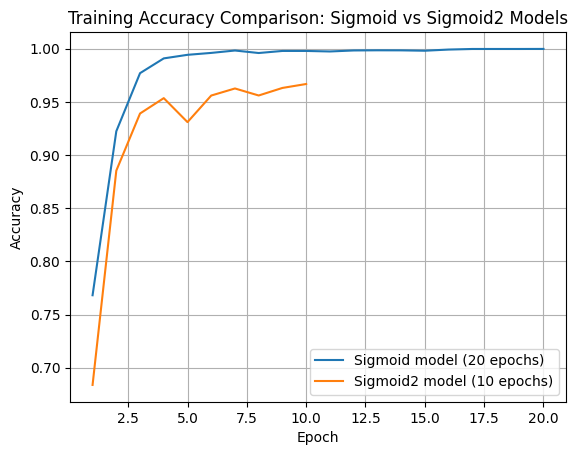

In [35]:


e = range(1, len(history_sigmoid.history['accuracy']) + 1)
e2 = range(1, len(history_sigmoid2.history['accuracy']) + 1)

plt.plot(e , history_sigmoid.history['accuracy'], label='Sigmoid model (20 epochs)')
plt.plot(e2 , history_sigmoid2.history['accuracy'], label='Sigmoid2 model (10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison: Sigmoid vs Sigmoid2 Models')
plt.legend()
plt.grid(True)
plt.show()

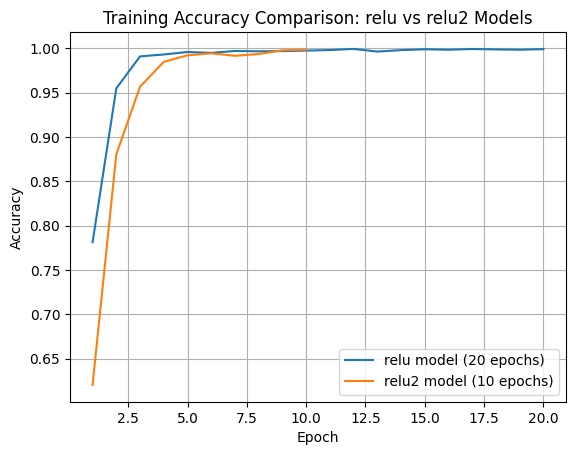

In [38]:
e = range(1, len(history.history['accuracy']) + 1)
e2 = range(1, len(history_relu2.history['accuracy']) + 1)

plt.plot(e , history.history['accuracy'], label='relu model (20 epochs)')
plt.plot(e2 , history_relu2.history['accuracy'], label='relu2 model (10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison: relu vs relu2 Models')
plt.legend()
plt.grid(True)
plt.show()

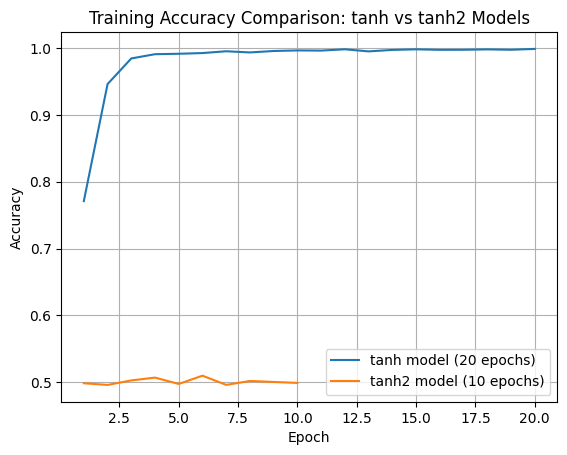

In [39]:
e = range(1, len(history_tanh.history['accuracy']) + 1)
e2 = range(1, len(history_tanh2.history['accuracy']) + 1)

plt.plot(e , history_tanh.history['accuracy'], label='tanh model (20 epochs)')
plt.plot(e2 , history_tanh2.history['accuracy'], label='tanh2 model (10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison: tanh vs tanh2 Models')
plt.legend()
plt.grid(True)
plt.show()

* (20 epochs, batch_size=20):
*
* **ReLU Model**
* Test Accuracy: 0.8068
* Test Loss: 2.0567


---


* **Sigmoid Model**
* Test Accuracy: 0.8008
* Test Loss: 1.3554



---

* **Tanh Model**
* Test Accuracy: 0.7686
* Test Loss: 1.4354


---


* (10 epochs, batch_size=64, learning_rate=0.01)
*
* **ReLU2 Model**
* Test Accuracy: 0.8225
* Test Loss: 1.2746


---


* **Sigmoid2 Model**
* Test Accuracy: 0.8124
* Test Loss: 0.6226


---


* **Tanh2 Model**
* Test Accuracy: 0.5000
* Test Loss: 0.6941